In [1]:
#exercise 2
from qutip import *
import numpy as np
import matplotlib.pyplot as plt

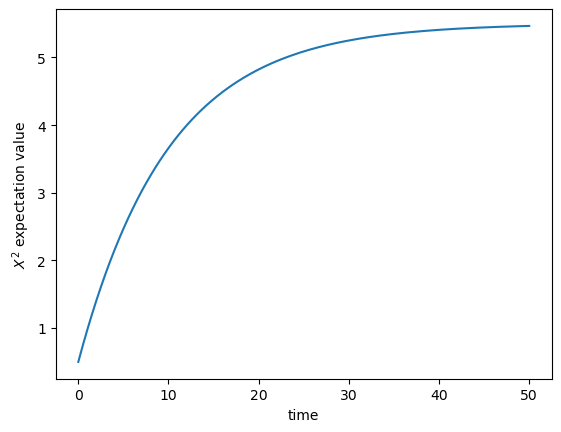

In [8]:
N = 100
omega = 1.0
gamma = 0.05
n_th = 5
time = np.linspace(0, 50, 200)

b = destroy(N)
b_dag = create(N)
H = omega * b_dag * b   #set hbar=1 and omit zero point energy

rho = fock_dm(N, 0)  #vacuum ground state, density matrix

c = [
    np.sqrt(2 * gamma * (n_th+1)) * b,
    np.sqrt(2 * gamma * n_th) * b_dag
]     #collapse operator

X = (b + b_dag) / np.sqrt(2)
X2 = X*X    #quadrature operator and its square

result = mesolve(H, rho, time, c, [X2])
expectation = result.expect[0]   #solve master equation and obatin expectation value

plt.plot(time, expectation)
plt.xlabel('time')
plt.ylabel(r'$X^2$ expectation value')
plt.show()

In [15]:
#part 2
X2_t0 = expect(X2, rho)

rho_1 = steadystate(H, c)
X2_tinf = expect(X2, rho_1)

print('X² expectation value at t = 0:', X2_t0)
print('X² expectation value at t → ∞:', X2_tinf)

X² expectation value at t = 0: 0.4999999999999999
X² expectation value at t → ∞: 5.499998671785919


In [16]:
result #result of mesolve function

<Result
  Solver: mesolve
  Solver stats:
    method: 'scipy zvode adams'
    init time: 0.0
    preparation time: 0.001539468765258789
    run time: 6.931451082229614
    solver: 'Master Equation Evolution'
    num_collapse: 2
  Time interval: [0.0, 50.0] (200 steps)
  Number of e_ops: 1
  State not saved.
>

In [17]:
dt = 1e-6
time1 = [0, dt]

result1 = mesolve(H, rho, time1, c, [X2])
X2_t0 = result1.expect[0][0]
X2_dt = result1.expect[0][1]

dX2_dt = (X2_dt - X2_t0) / dt

print('rate of change of X² at t = 0:', X2_dt)

rate of change of X² at t = 0: 0.5000004999999719


E:\Anaconda\envs\qutip-env\lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
